In [ ]:
# 各种import
import os
import torch
import shutil
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt
from conf import cal_accuracy
from model import alexnet
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

12.4


True

In [2]:
# ! ls
# %pwd
# # os.mkdir("./123")
%load_ext tensorboard
%tensorboard --logdir="./logs"

In [3]:
# 加载模型
model = alexnet().to(device)
model.load_state_dict(torch.load('./best_model/best_model.pth'))
model.eval()

/tmp/ipykernel_32695/3671697426.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./best_model/best_model.pth'))


alexnet(
  (conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=5, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=32, out_features=64, bias=True)
    (2): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [4]:
# 图象转为tensor && 像素颜色归一化
transform = transforms.Compose([
                                transforms.Resize(32), 
                                transforms.ToTensor(), 
                                transforms.Normalize((0.5, ), (0.5, ))])
test_set = datasets.MNIST(root="../mnist", train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=len(test_set), shuffle=False)

In [5]:
model.eval()
criterion = nn.CrossEntropyLoss().to(device)
correct = 0
total = 0
with torch.no_grad():
    for data, target in tqdm(test_loader):
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        _, y_pred = torch.max(output, 1)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)
        y_test = target
    accuracy = correct/total
    print(f"accuracy: {accuracy}, loss:{loss}")

100%|██████████| 1/1 [00:01<00:00,  1.53s/it]

accuracy: 0.9744, loss:0.2661409378051758


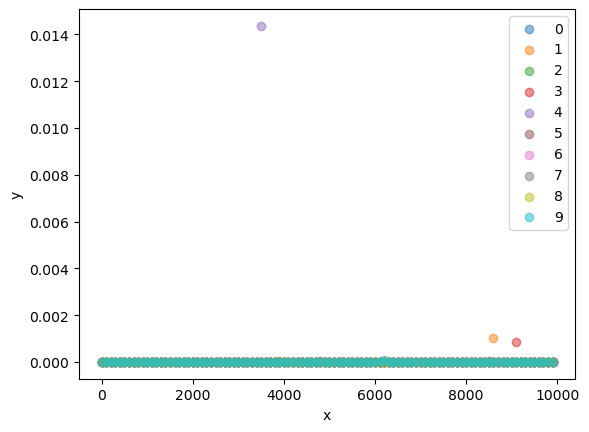

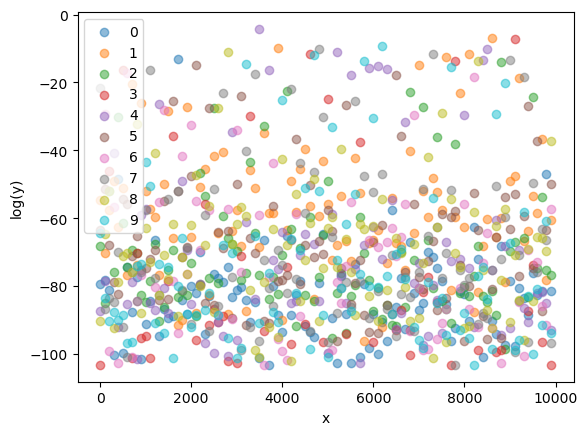

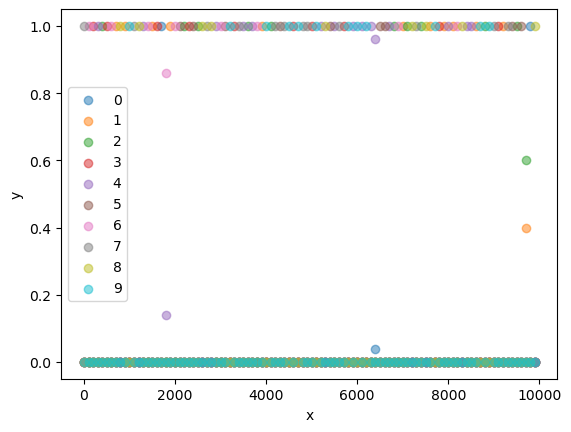

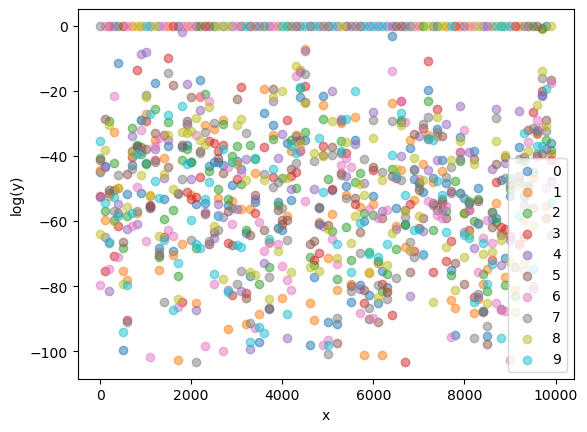

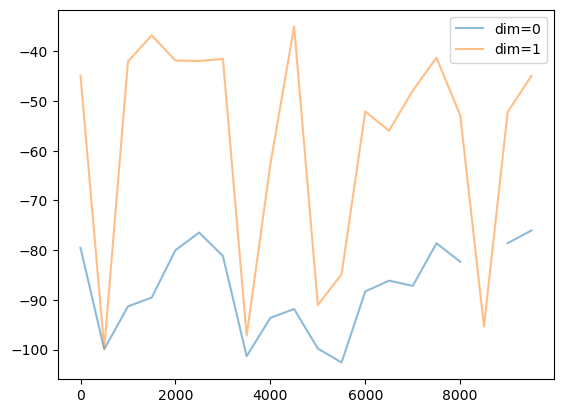

In [40]:
output1 = torch.softmax(output, dim=0).to('cpu')
output2 = torch.softmax(output, dim=1).to('cpu')

for i in range(len(output1.T)):
    plt.scatter(range(0, output1.shape[0], 100), output1.T[i][::100], alpha=0.5, label=i)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

for i in range(len(output1.T)):
    plt.scatter(range(0, output1.shape[0], 100), torch.log(output1.T[i][::100]), alpha=0.5, label=i)
plt.legend()
plt.xlabel('x')
plt.ylabel('log(y)')
plt.show()

for i in range(len(output2.T)):
    plt.scatter(range(0, output2.shape[0], 100), output2.T[i][::100], alpha=0.5, label=i)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

for i in range(len(output2.T)):
    plt.scatter(range(0, output2.shape[0], 100), torch.log(output2.T[i][::100]), alpha=0.5, label=i)
plt.legend()
plt.xlabel('x')
plt.ylabel('log(y)')
plt.show()

plt.plot(range(0, output1.shape[0], 500), torch.log(output1.T[0][::500]), alpha=0.5, label='dim=0')
plt.plot(range(0, output2.shape[0], 500), torch.log(output2.T[0][::500]), alpha=0.5, label='dim=1')
plt.legend()
plt.show()

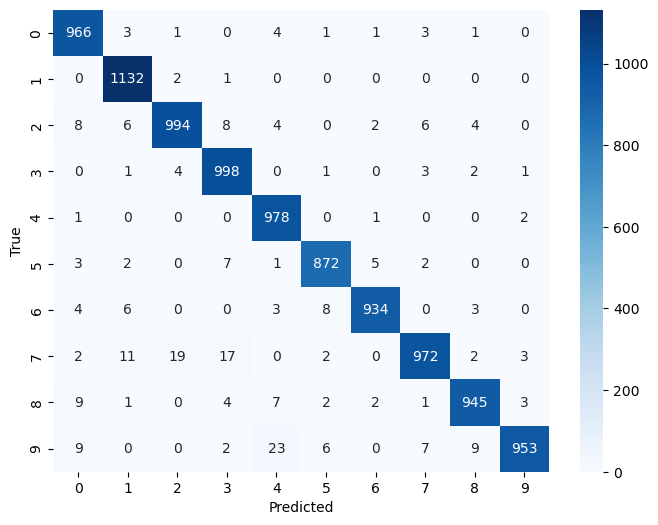

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.97      1.00      0.99      1135
           2       0.97      0.96      0.97      1032
           3       0.96      0.99      0.98      1010
           4       0.96      1.00      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.97      0.98       958
           7       0.98      0.95      0.96      1028
           8       0.98      0.97      0.97       974
           9       0.99      0.94      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [7]:
y_test, y_pred = y_test.to('cpu'), y_pred.to('cpu')
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print(classification_report(y_test, y_pred))